# News Classification via Textual Analysis and Metadata

### Libraries and Dataset Import

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import ftfy
import html
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


df= pd.read_csv("development.csv",delimiter=",", index_col="Id")
df_eval = pd.read_csv("evaluation.csv", delimiter=",", index_col="Id")

### *Source* Inspection

Source NaN: 0
Source Placeholders (\N): 294
Source Empty strings: 0
Number of sources: 1359


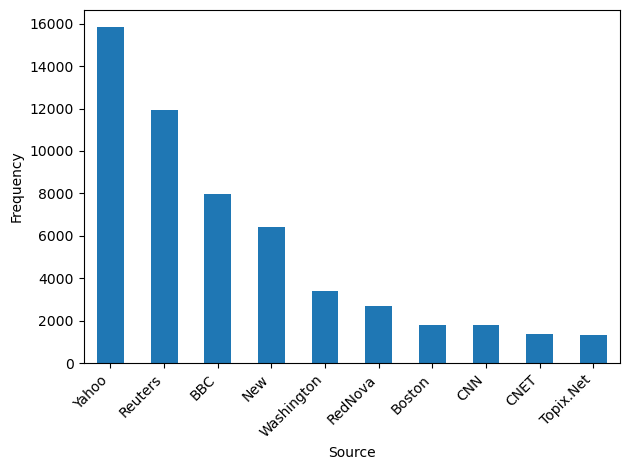

In [2]:
source_nan = df["source"].isna().sum()
source_placeholder = (df["source"] == "\\N").sum()
source_empty = (df['source'].astype(str).str.strip() == '').sum()

print(f"Source NaN: {source_nan}")
print(f"Source Placeholders (\\N): {source_placeholder}")
print(f"Source Empty strings: {source_empty}")

sources = df["source"].replace(["\\N", ""], np.nan).fillna("Other")

final_source_counts = sources.value_counts()
print(f"Number of sources: {len(final_source_counts)}")

top_sources = sources.value_counts().head(10)

plt.figure()
top_sources.plot(kind="bar")
plt.xlabel("Source")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
#plt.savefig("plot/top_sources.pdf", bbox_inches="tight")
plt.show()

### *PageRank* Inspection

In [3]:
pr_nan = df['page_rank'].isna().sum()
pr_placeholder = (df['page_rank']=='\\N').sum()
pr_empty = (df['page_rank'].astype(str).str.strip()=='').sum()
rank_5=np.array([df['page_rank']==5]).sum()
rank_vals=np.unique(df['page_rank'])

print(f"PageRank NaN: {pr_nan}")
print(f"PageRank Placeholders (\\N): {pr_placeholder}")
print(f"PageRank Empty strings: {pr_empty}")
print(f"Number of articles with PageRank 5: {rank_5}")
print(f"Distinct PageRank: {rank_vals}")

PageRank NaN: 0
PageRank Placeholders (\N): 0
PageRank Empty strings: 0
Number of articles with PageRank 5: 73891
Distinct PageRank: [2 3 4 5]


### *Timestamp* Inspection

In [4]:
time_nan = df['timestamp'].isna().sum()
time_placeholder = (df['timestamp']=='\\N').sum()
time_empty = (df['timestamp'].astype(str).str.strip()=='').sum()
time_useless=np.array([df['timestamp']=="0000-00-00 00:00:00"]).sum()

print(f"Timestamp NaN: {time_nan}")
print(f"Timestamp Placeholders (\\N): {time_placeholder}")
print(f"Timestamp Empty strings: {time_empty}")
print(f"Invalid dates (0000-00-00 00:00:00): {time_useless}")

Timestamp NaN: 0
Timestamp Placeholders (\N): 0
Timestamp Empty strings: 0
Invalid dates (0000-00-00 00:00:00): 27750


### *Title* Inspection

In [5]:
title_nan = df['title'].isna().sum()
title_placeholder = (df['title']== '\\N').sum()
title_empty = (df['title'].astype(str).str.strip()=='').sum()

print(f"Title NaN: {title_nan}")
print(f"Title Placeholders (\\N): {title_placeholder}")
print(f"Title Empty rows: {title_empty}")
print("Title sample:")
print(df['title'].sample(5))

Title NaN: 1
Title Placeholders (\N): 0
Title Empty rows: 2
Title sample:
Id
70965                 Orwell's 1984 'defines 20th century'
12902    Blake's TV interview to be allowed as evidence...
55960    Thousands of Lebanese gather for Gemayel's fun...
76654    Branson Launches Virgin Atlantic Flights to Au...
24496           London shares close higher \\n    (AFP)\\n
Name: title, dtype: object


### *Article* Inspection

In [6]:
article_nan = df['article'].isna().sum()
article_placeholder = (df['article']=='\\N').sum()
article_empty = (df['article'].astype(str).str.strip()=='').sum()

print(f"Article NaN: {article_nan}")
print(f"Article Placeholders (\\N): {article_placeholder}")
print(f"Article Empty rows: {article_empty}")
print("Article sample")
print(df['article'].sample(5))

Article NaN: 1
Article Placeholders (\N): 1874
Article Empty rows: 7
Article sample
Id
67392    The new Miss World, blonde Czech 18-year-old T...
77402    Sony Corp.&#39;s thriller ``The Grudge,&#39;&#...
28627    at least when it came to sending junk to its s...
6866     On February 15, Imax Adlabs will be seen drape...
49253    <p><a href="http://us.rd.yahoo.com/dailynews/r...
Name: article, dtype: object


### Feature Engineering

In [ ]:
def clean_title(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = ftfy.fix_text(text)
    text = html.unescape(text)
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s\.\,\-\%\$\€\£]", " ", text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def clean_article(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = ftfy.fix_text(text)
    text = html.unescape(text)
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'\b(a\s+href|href|img\s+src|nbsp|read\s+more|click\s+here)\b',' ', text, flags=re.IGNORECASE)
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s\.\,\-\%\$\€\£]", " ", text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def build_features(df):
    df = df.copy()

    df["source"] = (df["source"].replace(["\\N", ""], np.nan).fillna("Other").astype(str))

    dt = pd.to_datetime(df["timestamp"], errors="coerce")
    df["has_date"] = dt.notna().astype(int)
    df["quarter"] = dt.dt.quarter.fillna(-1).astype(int)
    df["is_weekend"] = dt.dt.dayofweek.isin([5, 6]).fillna(False).astype(int)

    title_clean = df["title"].replace("\\N", "").apply(clean_title)
    article_clean = df["article"].replace("\\N", "").apply(clean_article)
    df["text"] = (title_clean + " " + article_clean).str.strip()

    df = df[["text", "source", "page_rank", "has_date", "is_weekend", "quarter"]]

    return df

### *Source* processing inspection

In [25]:
min_freq = 5
real_sources = df["source"].replace(["\\N", ""], np.nan).dropna()
counts = real_sources.value_counts()
kept = counts[counts >= min_freq]

print("OHE categories (min_freq=5):", len(kept) + 1)  
print(f"Records with valid source encoded (%): {kept.sum() / len(real_sources) * 100:.2f}")

OHE categories (min_freq=5): 489
Records with valid source encoded (%): 98.09


### *Text* processing inspection

In [ ]:
sample_text = df.sample(5, random_state=42)[["title", "article"]]

sample_text["title_clean"] = (sample_text["title"].replace("\\N", "").apply(clean_title))
sample_text["article_clean"] = (sample_text["article"].replace("\\N", "").apply(clean_article))

for _, data in sample_text.iterrows():
    print("Original Title:")
    print(data["title"])
    print("Clean Title:")
    print(data["title_clean"])
    print("Original Article (first 200 chars):")
    print(str(data["article"])[:200])
    print("Clean Article (first 200 chars):")
    print(data["article_clean"][:200])
    print()

Original Title:
Care charity suspends Iraq work
Clean Title:
care charity suspends iraq work
Original Article (first 500 chars):
Aid agency Care International has suspended its work in Iraq after the abduction of a British-Iraqi 
Clean Article (first 500 chars):
aid agency care international has suspended its work in iraq after the abduction of a british-iraqi 

Original Title:
Rice: No memory of CIA warning of attack \
    (AP)\

Clean Title:
rice no memory of cia warning of attack ap
Original Article (first 500 chars):
<p><a href="http://us.rd.yahoo.com/dailynews/rss/politics/*http://news.yahoo.com/s/ap/20061002/ap_on
Clean Article (first 500 chars):
ap - secretary of state condoleezza rice said she cannot recall then-cia chief george tenet warning 

Original Title:
Alicia Markova, noted ballerina, dies
Clean Title:
alicia markova, noted ballerina, dies
Original Article (first 500 chars):
Alicia Markova, Britain's first great ballerina, has died. She was 94. Markova, only one of a ha

### Preprocessing and Model validation

In [8]:
text_cols = "text"
cat_cols = ["source"]
num_cols = ["page_rank", "has_date", "is_weekend", "quarter"]

X = df.drop(columns=['label'])
y = df['label']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

vectorizer = Pipeline([
    ("vec", TfidfVectorizer(
        sublinear_tf=True,
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.95,
        max_features=400_000   
    )),
    ("chi2", SelectKBest(chi2, k=80_000))
])

preprocess = ColumnTransformer(
    transformers=[
        ("text", vectorizer, text_cols),
        ("source", OneHotEncoder(
            handle_unknown="infrequent_if_exist",
            min_frequency=5,
            sparse_output=True
        ), cat_cols),
        ("num", "passthrough", num_cols),
    ]
)

pipeline = Pipeline([
    ("features", FunctionTransformer(build_features)),
    ("prep", preprocess),
    ("model", LinearSVC(class_weight="balanced", max_iter=10_000, random_state=42)),
])

param_grid = {
    "prep__text__chi2__k": [60_000, 80_000, 100_000],
    "model__C": [0.10, 0.15, 0.25, 0.40, 0.60],  
}

grid = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
)

grid.fit(X_train, y_train)
best_model = grid.best_estimator_
y_val_pred = best_model.predict(X_val)

/var/folders/_r/4kq58czx6cl9n68zbg2nc56r0000gn/T/ipykernel_13259/2710803371.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
/var/folders/_r/4kq58czx6cl9n68zbg2nc56r0000gn/T/ipykernel_13259/2710803371.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
/var/folders/_r/4kq58czx6cl9n68zbg2nc56r0000gn/T/ipykernel_13259/2710803371.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
/var/folders/_r/4kq58czx6cl9n68zbg2nc56r0000gn/T/ipykernel_13259/2710803371.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ens

### Quality assessment

Best parameters: {'model__C': 0.25, 'prep__text__chi2__k': 80000}
Validation Macro F1: 0.7002566225381122
              precision    recall  f1-score   support

           0     0.7394    0.7460    0.7427      4709
           1     0.7288    0.8008    0.7631      2118
           2     0.8182    0.8127    0.8155      2232
           3     0.6011    0.5068    0.5499      1995
           4     0.7816    0.9329    0.8506      1715
           5     0.5655    0.4581    0.5061      2611
           6     0.5796    0.8048    0.6739       620

    accuracy                         0.7081     16000
   macro avg     0.6877    0.7232    0.7003     16000
weighted avg     0.7017    0.7081    0.7018     16000



<Figure size 600x600 with 0 Axes>

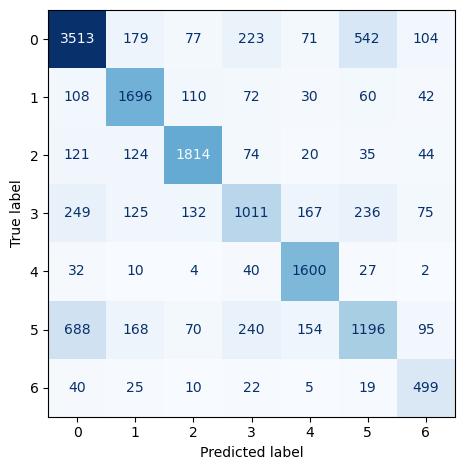

In [ ]:
print("Best parameters:", grid.best_params_)
print("Validation Macro F1:", f1_score(y_val, y_val_pred, average="macro"))
print(classification_report(y_val, y_val_pred, digits=4))

conf_matrix = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(6, 6))
ConfusionMatrixDisplay(confusion_matrix=conf_matrix).plot(cmap="Blues", colorbar=False)
plt.tight_layout()
#plt.savefig("plot/conf_matrix.pdf", bbox_inches="tight")
plt.show()

### TF-IDF effectiveness

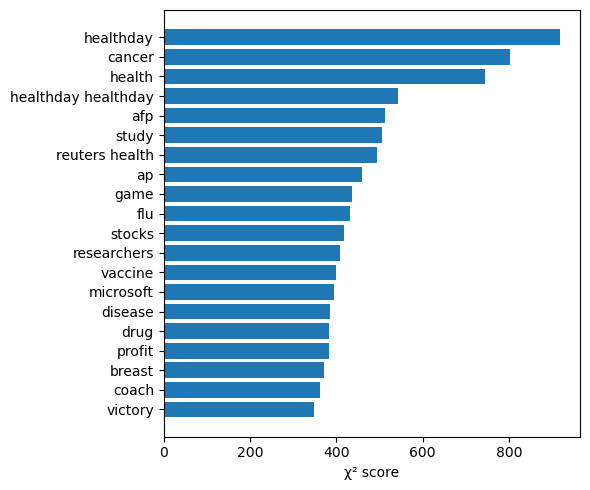

In [ ]:
pipe_text = best_model.named_steps["prep"].named_transformers_["text"]
tfidf = pipe_text.named_steps["vec"]
chi2_sel = pipe_text.named_steps["chi2"]

feature_names = np.array(tfidf.get_feature_names_out())
scores = chi2_sel.scores_

top_idx = np.argsort(scores)[-20:]
words = feature_names[top_idx]
vals = scores[top_idx]
order = np.argsort(vals)

plt.figure(figsize=(6, 5))
plt.barh(words[order], vals[order])
plt.xlabel("χ² score")
plt.tight_layout()
#plt.savefig("plot/top_words.pdf", bbox_inches="tight")
plt.show()

### Final submission

In [10]:
best_model.fit(X, y) 
pred_eval = best_model.predict(df_eval)

submission_df = pd.DataFrame({
    "Id": df_eval.index,
    "Predicted": pred_eval
})

#submission_df.to_csv("submission.csv", index=False)
print(submission_df.head())

   Id  Predicted
0   0          5
1   1          2
2   2          5
3   3          0
4   4          0
